(150, 4)


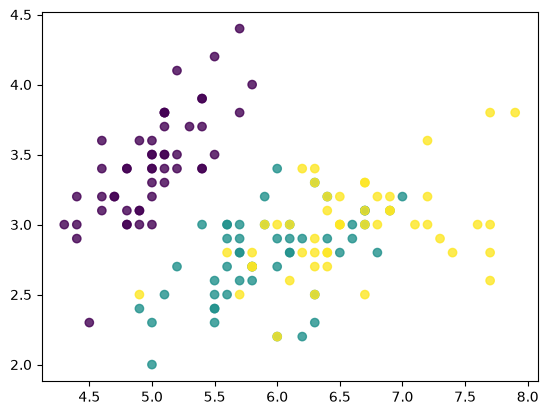

Train set: (120, 4)
Test set: (30, 4)


In [2]:
########################################
# Train test plit
########################################
# Importer NumPy
import numpy as np

# Importer Matplotlib pour les graphiques
import matplotlib.pyplot as plt

# Importer le jeu de données Iris depuis Scikit-Learn
from sklearn.datasets import load_iris

# Charger les données Iris
iris = load_iris()

# Récupérer les variables explicatives
X = iris.data

# Récupérer les classes cibles
y = iris.target

# Afficher la dimension des données
print(X.shape)

# Créer un nuage de points avec les deux premières variables
# La couleur des points dépend de leur classe
plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8)

# Afficher le graphique
plt.show()
# Importer la fonction pour séparer les données en ensemble
# d'entraînement (train) et ensemble de test
from sklearn.model_selection import train_test_split

# Séparer X et y en données d'entraînement et données de test
# test_size=0.2 → 20% des données pour le test
# random_state=5 → permet d'obtenir toujours la même séparation
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=5
)

# Afficher la taille de l'ensemble d'entraînement
print('Train set:', X_train.shape)

# Afficher la taille de l'ensemble de test
print('Test set:', X_test.shape)

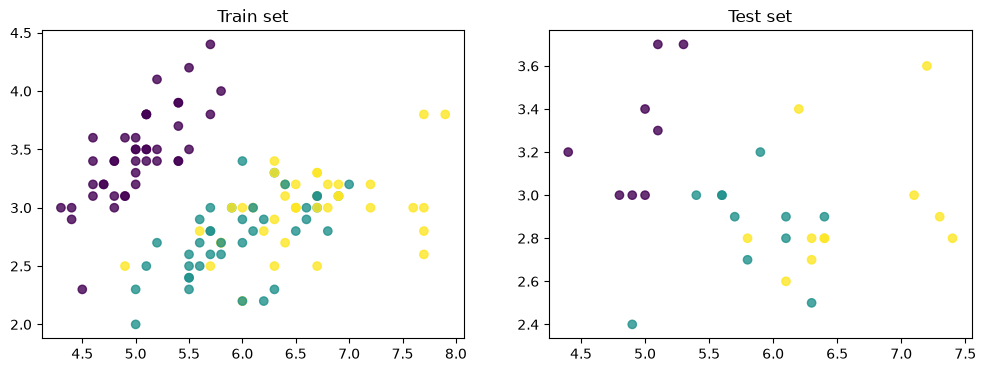

In [3]:



# Créer une figure de taille 12 × 4
plt.figure(figsize=(12, 4))

# Premier graphique : données d'entraînement
plt.subplot(121)

# Afficher les deux premières variables de X_train
# La couleur des points dépend de la classe y_train
plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    alpha=0.8
)

plt.title('Train set')


# Deuxième graphique : données de test
plt.subplot(122)

# Afficher les deux premières variables de X_test
# La couleur des points dépend de la classe y_test
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    alpha=0.8
)

plt.title('Test set')

# Afficher les graphiques
plt.show()



In [8]:
# Importer l'algorithme K plus proches voisins (KNN)
from sklearn.neighbors import KNeighborsClassifier

# Créer le modèle KNN avec 1 seul voisin
model = KNeighborsClassifier(n_neighbors=10)

# Entraîner le modèle avec les données d'entraînement
model.fit(X_train, y_train)

# Calculer et afficher le score sur les données d'entraînement
print('Train score:', model.score(X_train, y_train))

# Calculer et afficher le score sur les données de test 
print('Test score:', model.score(X_test, y_test))

Train score: 0.9833333333333333
Test score: 0.9666666666666667


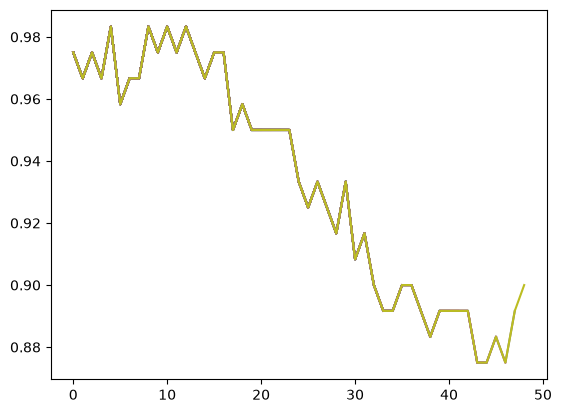

In [13]:
###############################################
# Validation de model via cross validation -> amelioration de model et 
###############################################

# Importer la fonction de validation croisée
from sklearn.model_selection import cross_val_score
# Effectuer une validation croisée avec 5 sous-échantillons (folds)
# pour évaluer la précision du modèle KNN

val_score= []
for i in range (1, 50):
    score=cross_val_score(
        KNeighborsClassifier(i),
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    ).mean()
    val_score.append(score)
    plt.plot (val_score)



[[1.         1.         0.95833333 0.95833333 0.95833333]
 [0.95833333 1.         0.95833333 0.95833333 0.95833333]
 [1.         1.         0.95833333 0.95833333 0.95833333]
 [1.         0.95833333 0.95833333 0.95833333 0.95833333]
 [1.         1.         1.         0.95833333 0.95833333]
 [0.95833333 0.95833333 0.95833333 0.95833333 0.95833333]
 [1.         0.95833333 0.95833333 0.95833333 0.95833333]
 [1.         0.95833333 0.95833333 0.95833333 0.95833333]
 [1.         1.         1.         0.95833333 0.95833333]
 [1.         1.         0.95833333 0.95833333 0.95833333]
 [1.         1.         1.         0.95833333 0.95833333]
 [1.         1.         0.95833333 0.95833333 0.95833333]
 [1.         1.         1.         0.95833333 0.95833333]
 [1.         0.95833333 1.         0.95833333 0.95833333]
 [1.         0.91666667 1.         0.95833333 0.95833333]
 [1.         0.95833333 1.         0.95833333 0.95833333]
 [1.         0.95833333 1.         0.95833333 0.95833333]
 [0.95833333 0

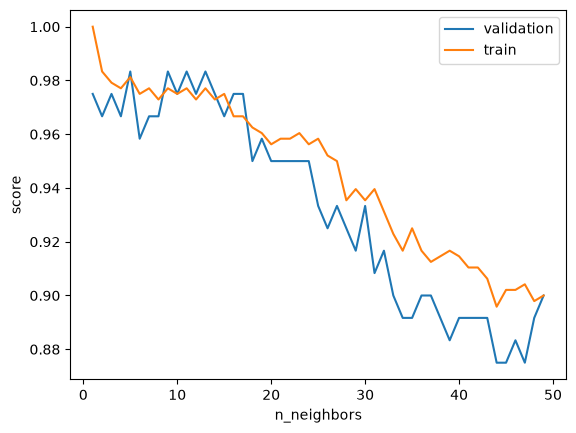

In [ ]:
###############################################
# Validation curve
###############################################
# Importer la fonction de courbe de validation
from sklearn.model_selection import validation_curve

# Créer le modèle KNN
model = KNeighborsClassifier()

# Créer les différentes valeurs de k à tester
k = np.arange(1, 50)

# Calculer les scores d'entraînement et de validation
train_score, val_score = validation_curve(
    model,
    X_train,
    y_train,
    param_name='n_neighbors',
    param_range=k,
    cv=5
)
print(val_score)
val_score.shape
# Tracer le score moyen de validation en fonction du nombre de voisins
plt.plot(k, val_score.mean(axis=1), label='validation')

# Tracer le score moyen d'entraînement
plt.plot(k, train_score.mean(axis=1), label='train')

# Nom de l'axe vertical
plt.ylabel('score')

# Nom de l'axe horizontal
plt.xlabel('n_neighbors')

# Afficher la légende
plt.legend()


In [25]:
###############################################
# Grid search cv
###############################################
# Importer GridSearchCV pour rechercher automatiquement les meilleurs paramètres
from sklearn.model_selection import GridSearchCV

# Définir les paramètres à tester
param_grid = {
    'n_neighbors': np.arange(1, 20),
    'metric': ['euclidean', 'manhattan']
}

# Créer la recherche par grille avec un modèle KNN
# cv=5 → validation croisée en 5 parties
grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)
grid.best_score_
grid.best_params_


{'metric': 'euclidean', 'n_neighbors': np.int64(5)}

In [26]:
model= grid.best_estimator_
model.score(X_test, y_test)

0.9333333333333333

In [27]:
# Importer la fonction qui permet de calculer la matrice de confusion
from sklearn.metrics import confusion_matrix

# Comparer les vraies valeurs y_test avec les prédictions du modèle
confusion_matrix(y_test, model.predict(X_test))

array([[ 8,  0,  0],
       [ 0,  9,  2],
       [ 0,  0, 11]])

[ 9 19 28 38 48 57 67 76 86 96]


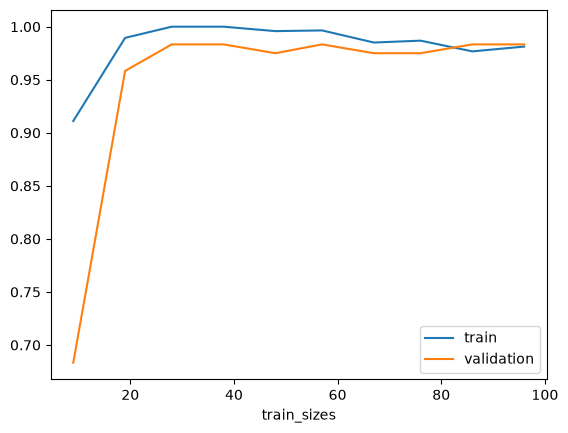

In [ ]:
###############################################
# Learning curve 
###############################################
# Importer la fonction learning_curve
from sklearn.model_selection import learning_curve

# Calculer la courbe d'apprentissage du modèle
N, train_score,val_score=learning_curve(
    model,
    X_train,
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5
)
print(N)

# Tracer le score d'entraînement en fonction de la taille des données
plt.plot(N, train_score.mean(axis=1), label='train')

# Tracer le score de validation
plt.plot(N, val_score.mean(axis=1), label='validation')

# Nom de l'axe horizontal
plt.xlabel('train_sizes')

# Afficher la légende
plt.legend()

# Afficher le graphique
plt.show()
